# Manual Tuning, Grid Search, Feature Discovery, And Temporal Validation

This notebook keeps the project notebook-first while adding two stronger capabilities:
- temporal grid search so each model can pick its best validation-time hyperparameters
- feature discovery so omitted origination-time feature groups can be screened without leaking future information

The workflow is always chronological: train -> validation -> test.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (
        candidate.resolve()
        for candidate in [Path.cwd(), Path.cwd().parent]
        if (candidate / 'src').exists() and (candidate / 'notebooks').exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate the project root from the current notebook session.')

sys.path.append(str(PROJECT_ROOT / 'src'))

import copy
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from experiment import run_experiment, run_feature_search, run_manual_sweep
from preprocess import ISSUE_DATE_COLUMN, load_processed_data
from reporting import write_temporal_report

BASE_CONFIG = {
    'processed_data_path': str(PROJECT_ROOT / 'data' / 'processed' / 'loan_clean.csv'),
    'output_path': str(PROJECT_ROOT / 'data' / 'processed' / 'test_with_pd_best_model.csv'),
    'report_output_path': str(PROJECT_ROOT / 'reports' / 'temporal_model_report.md'),
    'random_state': 42,
    'sample_frac': 0.10,
    'generate_full_report': True,
    'use_grid_search': True,
    'grid_search_models': [
        'logistic_regression',
        'random_forest',
        'hist_gradient_boosting',
        'xgboost',
    ],
    'temporal_split': {
        'train_end': '2016-01-01',
        'valid_end': '2017-01-01',
    },
    'enabled_models': [
        'logistic_regression',
        'random_forest',
        'hist_gradient_boosting',
        'xgboost',
    ],
    'feature_flags': {
        'use_additional_numeric_features': True,
        'use_engineered_features': True,
        'use_extended_engineered_features': True,
        'use_home_ownership_dummies': True,
        'use_purpose_dummies': True,
        'use_fico_bucket_dummies': True,
        'use_verification_status_dummies': True,
        'use_grade_dummies': False,
        'use_initial_list_status_dummies': False,
        'use_application_type_dummies': False,
    },
    'meta_columns': ['sample_id', ISSUE_DATE_COLUMN, 'loan_amnt', 'annual_inc', 'fico_range_low', 'term_months', 'int_rate', 'revol_util'],
    'model_params': {
        'logistic_regression': {
            'C': 1.0,
            'max_iter': 1000,
            'class_weight': None,
        },
        'random_forest': {
            'n_estimators': 120,
            'max_depth': 14,
            'min_samples_split': 100,
            'min_samples_leaf': 25,
            'max_features': 'sqrt',
            'n_jobs': -1,
            'random_state': 42,
        },
        'hist_gradient_boosting': {
            'learning_rate': 0.05,
            'max_iter': 150,
            'max_depth': 6,
            'max_leaf_nodes': 31,
            'min_samples_leaf': 50,
            'l2_regularization': 0.0,
            'early_stopping': False,
        },
        'xgboost': {
            'n_estimators': 120,
            'max_depth': 6,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'min_child_weight': 5,
            'reg_lambda': 1.0,
            'random_state': 42,
            'n_jobs': -1,
        },
    },
    'param_grid': {
        'logistic_regression': {
            'C': [0.5, 2.0],
            'class_weight': [None, 'balanced'],
        },
        'random_forest': {
            'n_estimators': [80, 120],
            'max_depth': [10, 14],
        },
        'hist_gradient_boosting': {
            'learning_rate': [0.03, 0.05],
            'max_depth': [4, 6],
        },
        'xgboost': {
            'n_estimators': [80, 120],
            'max_depth': [4, 6],
        },
    },
    'run_feature_search': True,
    'feature_search': {
        'search_model': 'xgboost',
        'candidate_flags': [
            'use_grade_dummies',
            'use_initial_list_status_dummies',
            'use_application_type_dummies',
        ],
    },
    'run_manual_sweep': False,
    'sweep_model': 'xgboost',
    'manual_sweep': {
        'logistic_regression': [
            {'C': 0.5, 'class_weight': None},
            {'C': 2.0, 'class_weight': None},
            {'C': 2.0, 'class_weight': 'balanced'},
        ],
        'random_forest': [
            {'n_estimators': 80, 'max_depth': 10, 'min_samples_leaf': 30},
            {'n_estimators': 120, 'max_depth': 14, 'min_samples_leaf': 25},
            {'n_estimators': 160, 'max_depth': 16, 'min_samples_leaf': 20},
        ],
        'hist_gradient_boosting': [
            {'learning_rate': 0.03, 'max_iter': 120, 'max_depth': 4},
            {'learning_rate': 0.05, 'max_iter': 150, 'max_depth': 6},
            {'learning_rate': 0.08, 'max_iter': 180, 'max_depth': 7},
        ],
        'xgboost': [
            {'n_estimators': 80, 'max_depth': 4, 'learning_rate': 0.05},
            {'n_estimators': 120, 'max_depth': 6, 'learning_rate': 0.05},
            {'n_estimators': 160, 'max_depth': 7, 'learning_rate': 0.08},
        ],
    },
}

CURRENT_CONFIG = copy.deepcopy(BASE_CONFIG)
print(json.dumps(CURRENT_CONFIG, indent=2))

{
  "processed_data_path": "/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/loan_clean.csv",
  "output_path": "/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/test_with_pd_best_model.csv",
  "report_output_path": "/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/reports/temporal_model_report.md",
  "random_state": 42,
  "sample_frac": 0.1,
  "generate_full_report": true,
  "use_grid_search": true,
  "grid_search_models": [
    "logistic_regression",
    "random_forest",
    "hist_gradient_boosting",
    "xgboost"
  ],
  "temporal_split": {
    "train_end": "2016-01-01",
    "valid_end": "2017-01-01"
  },
  "enabled_models": [
    "logistic_regression",
    "random_forest",
    "hist_gradient_boosting",
    "xgboost"
  ],
  "feature_flags": {
    "use_additional_numeric_features": true,
    "use_engineered_features": true,
    "use_extended_engineered_features": true,
    "use_home_ownership_dummies": true,
    "use_purpose_d

## Widget Panel For Quick Manual Tuning

The config block above remains the authoritative source of truth.
Use the widgets below for quick manual adjustments, but edit `CURRENT_CONFIG['param_grid']` directly when you want to expand or shrink the grid-search space.

In [2]:
import ipywidgets as widgets
from IPython.display import display

enabled_models_widget = widgets.SelectMultiple(
    options=tuple(CURRENT_CONFIG['enabled_models']),
    value=tuple(CURRENT_CONFIG['enabled_models']),
    description='models',
    rows=4,
)
sample_frac_widget = widgets.FloatSlider(
    value=CURRENT_CONFIG['sample_frac'],
    min=0.05,
    max=1.0,
    step=0.05,
    description='sample',
    readout_format='.2f',
)
grid_toggle_widget = widgets.Checkbox(value=CURRENT_CONFIG['use_grid_search'], description='run grid search')
feature_search_toggle_widget = widgets.Checkbox(value=CURRENT_CONFIG['run_feature_search'], description='run feature search')
sweep_toggle_widget = widgets.Checkbox(value=CURRENT_CONFIG['run_manual_sweep'], description='run manual sweep')
sweep_model_widget = widgets.Dropdown(options=CURRENT_CONFIG['enabled_models'], value=CURRENT_CONFIG['sweep_model'], description='sweep model')
report_toggle_widget = widgets.Checkbox(value=CURRENT_CONFIG['generate_full_report'], description='generate report')

additional_numeric_widget = widgets.Checkbox(value=CURRENT_CONFIG['feature_flags']['use_additional_numeric_features'], description='additional numeric')
engineered_widget = widgets.Checkbox(value=CURRENT_CONFIG['feature_flags']['use_engineered_features'], description='base engineered')
extended_engineered_widget = widgets.Checkbox(value=CURRENT_CONFIG['feature_flags']['use_extended_engineered_features'], description='extended engineered')
home_widget = widgets.Checkbox(value=CURRENT_CONFIG['feature_flags']['use_home_ownership_dummies'], description='home dummies')
purpose_widget = widgets.Checkbox(value=CURRENT_CONFIG['feature_flags']['use_purpose_dummies'], description='purpose dummies')
fico_widget = widgets.Checkbox(value=CURRENT_CONFIG['feature_flags']['use_fico_bucket_dummies'], description='fico bucket dummies')
verification_widget = widgets.Checkbox(value=CURRENT_CONFIG['feature_flags']['use_verification_status_dummies'], description='verification dummies')
grade_widget = widgets.Checkbox(value=CURRENT_CONFIG['feature_flags']['use_grade_dummies'], description='grade dummies')
listing_widget = widgets.Checkbox(value=CURRENT_CONFIG['feature_flags']['use_initial_list_status_dummies'], description='listing-status dummies')
application_widget = widgets.Checkbox(value=CURRENT_CONFIG['feature_flags']['use_application_type_dummies'], description='application-type dummies')

lr_c_widget = widgets.FloatLogSlider(value=CURRENT_CONFIG['model_params']['logistic_regression']['C'], base=10, min=-2, max=1, step=0.1, description='LR C')
lr_weight_widget = widgets.Dropdown(options=[('None', None), ('balanced', 'balanced')], value=CURRENT_CONFIG['model_params']['logistic_regression']['class_weight'], description='LR weight')

rf_estimators_widget = widgets.IntSlider(value=CURRENT_CONFIG['model_params']['random_forest']['n_estimators'], min=40, max=200, step=20, description='RF trees')
rf_depth_widget = widgets.IntSlider(value=CURRENT_CONFIG['model_params']['random_forest']['max_depth'], min=4, max=20, step=2, description='RF depth')
rf_leaf_widget = widgets.IntSlider(value=CURRENT_CONFIG['model_params']['random_forest']['min_samples_leaf'], min=5, max=40, step=5, description='RF leaf')

hgb_lr_widget = widgets.FloatSlider(value=CURRENT_CONFIG['model_params']['hist_gradient_boosting']['learning_rate'], min=0.01, max=0.20, step=0.01, description='HGB lr', readout_format='.2f')
hgb_iter_widget = widgets.IntSlider(value=CURRENT_CONFIG['model_params']['hist_gradient_boosting']['max_iter'], min=50, max=220, step=10, description='HGB iter')
hgb_depth_widget = widgets.IntSlider(value=CURRENT_CONFIG['model_params']['hist_gradient_boosting']['max_depth'], min=2, max=12, step=1, description='HGB depth')

xgb_estimators_widget = widgets.IntSlider(value=CURRENT_CONFIG['model_params']['xgboost']['n_estimators'], min=40, max=220, step=20, description='XGB trees')
xgb_depth_widget = widgets.IntSlider(value=CURRENT_CONFIG['model_params']['xgboost']['max_depth'], min=2, max=10, step=1, description='XGB depth')
xgb_lr_widget = widgets.FloatSlider(value=CURRENT_CONFIG['model_params']['xgboost']['learning_rate'], min=0.01, max=0.20, step=0.01, description='XGB lr', readout_format='.2f')
xgb_subsample_widget = widgets.FloatSlider(value=CURRENT_CONFIG['model_params']['xgboost']['subsample'], min=0.5, max=1.0, step=0.05, description='XGB subsample', readout_format='.2f')
xgb_colsample_widget = widgets.FloatSlider(value=CURRENT_CONFIG['model_params']['xgboost']['colsample_bytree'], min=0.5, max=1.0, step=0.05, description='XGB colsample', readout_format='.2f')
xgb_child_weight_widget = widgets.IntSlider(value=CURRENT_CONFIG['model_params']['xgboost']['min_child_weight'], min=1, max=10, step=1, description='XGB child')
xgb_lambda_widget = widgets.FloatSlider(value=CURRENT_CONFIG['model_params']['xgboost']['reg_lambda'], min=0.0, max=5.0, step=0.25, description='XGB lambda', readout_format='.2f')

preview_output = widgets.Output()
apply_button = widgets.Button(description='Apply widgets', button_style='success')
reset_button = widgets.Button(description='Reset to base')

def show_config_preview():
    with preview_output:
        preview_output.clear_output()
        print(json.dumps(CURRENT_CONFIG, indent=2))

def apply_widget_values(_=None):
    CURRENT_CONFIG['enabled_models'] = list(enabled_models_widget.value)
    CURRENT_CONFIG['sample_frac'] = float(sample_frac_widget.value)
    CURRENT_CONFIG['use_grid_search'] = bool(grid_toggle_widget.value)
    CURRENT_CONFIG['run_feature_search'] = bool(feature_search_toggle_widget.value)
    CURRENT_CONFIG['run_manual_sweep'] = bool(sweep_toggle_widget.value)
    CURRENT_CONFIG['sweep_model'] = sweep_model_widget.value
    CURRENT_CONFIG['generate_full_report'] = bool(report_toggle_widget.value)
    CURRENT_CONFIG['grid_search_models'] = list(CURRENT_CONFIG['enabled_models'])

    CURRENT_CONFIG['feature_flags']['use_additional_numeric_features'] = bool(additional_numeric_widget.value)
    CURRENT_CONFIG['feature_flags']['use_engineered_features'] = bool(engineered_widget.value)
    CURRENT_CONFIG['feature_flags']['use_extended_engineered_features'] = bool(extended_engineered_widget.value)
    CURRENT_CONFIG['feature_flags']['use_home_ownership_dummies'] = bool(home_widget.value)
    CURRENT_CONFIG['feature_flags']['use_purpose_dummies'] = bool(purpose_widget.value)
    CURRENT_CONFIG['feature_flags']['use_fico_bucket_dummies'] = bool(fico_widget.value)
    CURRENT_CONFIG['feature_flags']['use_verification_status_dummies'] = bool(verification_widget.value)
    CURRENT_CONFIG['feature_flags']['use_grade_dummies'] = bool(grade_widget.value)
    CURRENT_CONFIG['feature_flags']['use_initial_list_status_dummies'] = bool(listing_widget.value)
    CURRENT_CONFIG['feature_flags']['use_application_type_dummies'] = bool(application_widget.value)

    CURRENT_CONFIG['model_params']['logistic_regression']['C'] = float(lr_c_widget.value)
    CURRENT_CONFIG['model_params']['logistic_regression']['class_weight'] = lr_weight_widget.value
    CURRENT_CONFIG['model_params']['random_forest']['n_estimators'] = int(rf_estimators_widget.value)
    CURRENT_CONFIG['model_params']['random_forest']['max_depth'] = int(rf_depth_widget.value)
    CURRENT_CONFIG['model_params']['random_forest']['min_samples_leaf'] = int(rf_leaf_widget.value)
    CURRENT_CONFIG['model_params']['hist_gradient_boosting']['learning_rate'] = float(hgb_lr_widget.value)
    CURRENT_CONFIG['model_params']['hist_gradient_boosting']['max_iter'] = int(hgb_iter_widget.value)
    CURRENT_CONFIG['model_params']['hist_gradient_boosting']['max_depth'] = int(hgb_depth_widget.value)
    CURRENT_CONFIG['model_params']['xgboost']['n_estimators'] = int(xgb_estimators_widget.value)
    CURRENT_CONFIG['model_params']['xgboost']['max_depth'] = int(xgb_depth_widget.value)
    CURRENT_CONFIG['model_params']['xgboost']['learning_rate'] = float(xgb_lr_widget.value)
    CURRENT_CONFIG['model_params']['xgboost']['subsample'] = float(xgb_subsample_widget.value)
    CURRENT_CONFIG['model_params']['xgboost']['colsample_bytree'] = float(xgb_colsample_widget.value)
    CURRENT_CONFIG['model_params']['xgboost']['min_child_weight'] = int(xgb_child_weight_widget.value)
    CURRENT_CONFIG['model_params']['xgboost']['reg_lambda'] = float(xgb_lambda_widget.value)
    show_config_preview()

def reset_to_base(_=None):
    global CURRENT_CONFIG
    CURRENT_CONFIG = copy.deepcopy(BASE_CONFIG)
    enabled_models_widget.value = tuple(CURRENT_CONFIG['enabled_models'])
    sample_frac_widget.value = CURRENT_CONFIG['sample_frac']
    grid_toggle_widget.value = CURRENT_CONFIG['use_grid_search']
    feature_search_toggle_widget.value = CURRENT_CONFIG['run_feature_search']
    sweep_toggle_widget.value = CURRENT_CONFIG['run_manual_sweep']
    sweep_model_widget.value = CURRENT_CONFIG['sweep_model']
    report_toggle_widget.value = CURRENT_CONFIG['generate_full_report']
    additional_numeric_widget.value = CURRENT_CONFIG['feature_flags']['use_additional_numeric_features']
    engineered_widget.value = CURRENT_CONFIG['feature_flags']['use_engineered_features']
    extended_engineered_widget.value = CURRENT_CONFIG['feature_flags']['use_extended_engineered_features']
    home_widget.value = CURRENT_CONFIG['feature_flags']['use_home_ownership_dummies']
    purpose_widget.value = CURRENT_CONFIG['feature_flags']['use_purpose_dummies']
    fico_widget.value = CURRENT_CONFIG['feature_flags']['use_fico_bucket_dummies']
    verification_widget.value = CURRENT_CONFIG['feature_flags']['use_verification_status_dummies']
    grade_widget.value = CURRENT_CONFIG['feature_flags']['use_grade_dummies']
    listing_widget.value = CURRENT_CONFIG['feature_flags']['use_initial_list_status_dummies']
    application_widget.value = CURRENT_CONFIG['feature_flags']['use_application_type_dummies']
    lr_c_widget.value = CURRENT_CONFIG['model_params']['logistic_regression']['C']
    lr_weight_widget.value = CURRENT_CONFIG['model_params']['logistic_regression']['class_weight']
    rf_estimators_widget.value = CURRENT_CONFIG['model_params']['random_forest']['n_estimators']
    rf_depth_widget.value = CURRENT_CONFIG['model_params']['random_forest']['max_depth']
    rf_leaf_widget.value = CURRENT_CONFIG['model_params']['random_forest']['min_samples_leaf']
    hgb_lr_widget.value = CURRENT_CONFIG['model_params']['hist_gradient_boosting']['learning_rate']
    hgb_iter_widget.value = CURRENT_CONFIG['model_params']['hist_gradient_boosting']['max_iter']
    hgb_depth_widget.value = CURRENT_CONFIG['model_params']['hist_gradient_boosting']['max_depth']
    xgb_estimators_widget.value = CURRENT_CONFIG['model_params']['xgboost']['n_estimators']
    xgb_depth_widget.value = CURRENT_CONFIG['model_params']['xgboost']['max_depth']
    xgb_lr_widget.value = CURRENT_CONFIG['model_params']['xgboost']['learning_rate']
    xgb_subsample_widget.value = CURRENT_CONFIG['model_params']['xgboost']['subsample']
    xgb_colsample_widget.value = CURRENT_CONFIG['model_params']['xgboost']['colsample_bytree']
    xgb_child_weight_widget.value = CURRENT_CONFIG['model_params']['xgboost']['min_child_weight']
    xgb_lambda_widget.value = CURRENT_CONFIG['model_params']['xgboost']['reg_lambda']
    show_config_preview()

apply_button.on_click(apply_widget_values)
reset_button.on_click(reset_to_base)

controls = widgets.VBox([
    widgets.HTML('<b>Run controls</b>'),
    widgets.HBox([enabled_models_widget, widgets.VBox([sample_frac_widget, grid_toggle_widget, feature_search_toggle_widget, sweep_toggle_widget, sweep_model_widget, report_toggle_widget])]),
    widgets.HTML('<b>Feature flags</b>'),
    widgets.VBox([additional_numeric_widget, engineered_widget, extended_engineered_widget, home_widget, purpose_widget, fico_widget, verification_widget, grade_widget, listing_widget, application_widget]),
    widgets.HTML('<b>Base model parameters</b>'),
    widgets.VBox([lr_c_widget, lr_weight_widget, rf_estimators_widget, rf_depth_widget, rf_leaf_widget, hgb_lr_widget, hgb_iter_widget, hgb_depth_widget, xgb_estimators_widget, xgb_depth_widget, xgb_lr_widget, xgb_subsample_widget, xgb_colsample_widget, xgb_child_weight_widget, xgb_lambda_widget]),
    widgets.HBox([apply_button, reset_button]),
    preview_output,
])
display(controls)
apply_widget_values()

## 1. Load The Processed Modeling Table

The modeling notebook expects the cleaned dataset created by the exploratory notebook.
Because the workflow is temporal, `issue_date` must be present in the processed file.

In [3]:
processed_path = Path(CURRENT_CONFIG['processed_data_path'])
if not processed_path.exists():
    raise FileNotFoundError(f'Processed dataset not found at {processed_path}. Run exploratory_analysis.ipynb first.')

df_model = load_processed_data(processed_path)
if ISSUE_DATE_COLUMN not in df_model.columns:
    raise KeyError('The processed dataset does not include issue_date. Regenerate it from the exploratory notebook.')

print(f'Loaded {len(df_model):,} rows from {processed_path}.')
display(df_model.head())

Loaded 1,345,310 rows from /Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/loan_clean.csv.


,sample_id,issue_date,loan_amnt,annual_inc,fico_range_low,dti,emp_length,term_months,int_rate,installment,...,verification_status_Verified,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,initial_list_status_w,application_type_Joint App,default
0,0,2015-12-01,3600.0,55000.0,675.0,5.91,10.0,36.0,13.99,123.03,...,0,0,1,0,0,0,0,1,0,0
1,1,2015-12-01,24700.0,65000.0,715.0,16.06,10.0,36.0,11.99,820.28,...,0,0,1,0,0,0,0,1,0,0
2,2,2015-12-01,20000.0,63000.0,695.0,10.78,10.0,60.0,10.78,432.66,...,0,1,0,0,0,0,0,1,1,0
3,4,2015-12-01,10400.0,104433.0,695.0,25.37,3.0,60.0,22.45,289.91,...,0,0,0,0,0,1,0,1,0,0
4,5,2015-12-01,11950.0,34000.0,690.0,10.20,4.0,36.0,13.44,405.18,...,0,0,1,0,0,0,0,1,0,0


## 2. Interactive Temporal Experiment

This run uses the current widget and config values.
If `sample_frac < 1.0`, the notebook samples within each temporal partition for faster iteration, but the split order remains chronological.

In [4]:
interactive_result = run_experiment(CURRENT_CONFIG, df_model)
interactive_split_summary = interactive_result['prepared_data']['split_summary'].copy()
interactive_split_summary['default_rate'] = interactive_split_summary['default_rate'].round(4)
display(interactive_split_summary)

,partition,rows,default_rate,min_issue_date,max_issue_date
0,train,82660,0.1842,2007-07-01,2015-12-01
1,validation,29310,0.2328,2016-01-01,2016-12-01
2,test,22561,0.2128,2017-01-01,2018-12-01


## 3. Validation Ranking For Model Selection

Only validation metrics are allowed to rank candidate models.
If grid search is enabled, each model family first selects its best hyperparameter block on the validation period.

In [5]:
validation_display = interactive_result['validation_table'][[
    'validation_rank',
    'model_name',
    'search_mode',
    'search_candidates',
    'params',
    'feature_count',
    'validation_auc',
    'validation_ks',
    'validation_brier',
    'calibration_summary',
]].copy()
for column in ['validation_auc', 'validation_ks', 'validation_brier']:
    validation_display[column] = validation_display[column].round(4)
validation_display

,validation_rank,model_name,search_mode,search_candidates,params,feature_count,validation_auc,validation_ks,validation_brier,calibration_summary
0,1,XGBoost,grid_search,4,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",51,0.7124,0.3081,0.1636,Underestimates risk in the highest-PD bins.
1,2,HistGradientBoosting,grid_search,4,"{""early_stopping"": false, ""l2_regularization"":...",51,0.7118,0.3075,0.1635,Underestimates risk in the highest-PD bins.
2,3,Logistic Regression,grid_search,4,"{""C"": 0.5, ""class_weight"": ""balanced"", ""max_it...",51,0.7113,0.3066,0.2108,Overestimates risk in the highest-PD bins.
3,4,Random Forest,grid_search,4,"{""max_depth"": 14, ""max_features"": ""sqrt"", ""min...",51,0.7091,0.3081,0.1646,Underestimates risk in the highest-PD bins.


## 4. Grid Search Candidate Table

This section shows every parameter combination evaluated on the validation period.
It lets you inspect whether the winning configuration is robust or only narrowly ahead.

In [6]:
if CURRENT_CONFIG['use_grid_search'] and not interactive_result['grid_search_table'].empty:
    grid_search_display = interactive_result['grid_search_table'][[
        'model_name',
        'search_rank',
        'params',
        'validation_auc',
        'validation_ks',
        'validation_brier',
    ]].copy()
    for column in ['validation_auc', 'validation_ks', 'validation_brier']:
        grid_search_display[column] = grid_search_display[column].round(4)
    display(grid_search_display)
else:
    print("Grid search is disabled. Turn on CURRENT_CONFIG['use_grid_search'] to search over CURRENT_CONFIG['param_grid'].")

,model_name,search_rank,params,validation_auc,validation_ks,validation_brier
0,Logistic Regression,1,"{""C"": 0.5, ""class_weight"": ""balanced"", ""max_it...",0.7113,0.3066,0.2108
1,Logistic Regression,2,"{""C"": 2.0, ""class_weight"": ""balanced"", ""max_it...",0.7113,0.3067,0.2108
2,Logistic Regression,3,"{""C"": 2.0, ""class_weight"": null, ""max_iter"": 1...",0.7110,0.3061,0.1636
3,Logistic Regression,4,"{""C"": 0.5, ""class_weight"": null, ""max_iter"": 1...",0.7110,0.3060,0.1636
4,Random Forest,1,"{""max_depth"": 14, ""max_features"": ""sqrt"", ""min...",0.7091,0.3081,0.1646
5,Random Forest,2,"{""max_depth"": 14, ""max_features"": ""sqrt"", ""min...",0.7082,0.3070,0.1647
6,Random Forest,3,"{""max_depth"": 10, ""max_features"": ""sqrt"", ""min...",0.7066,0.3002,0.1653
7,Random Forest,4,"{""max_depth"": 10, ""max_features"": ""sqrt"", ""min...",0.7064,0.3022,0.1653
8,HistGradientBoosting,1,"{""early_stopping"": false, ""l2_regularization"":...",0.7118,0.3075,0.1635
9,HistGradientBoosting,2,"{""early_stopping"": false, ""l2_regularization"":...",0.7115,0.3075,0.1633


## 5. Feature Discovery On Omitted Feature Groups

This screen holds the main feature set fixed, then adds one omitted feature group at a time.
The ranking is based on validation lift only, so it remains leakage-safe.

In [7]:
if CURRENT_CONFIG['run_feature_search']:
    interactive_feature_search = run_feature_search(CURRENT_CONFIG, df_model)
    feature_search_display = interactive_feature_search['feature_search_table'][[
        'feature_rank',
        'feature_group',
        'feature_flag',
        'search_model',
        'search_mode',
        'added_feature_count',
        'added_columns_preview',
        'validation_auc',
        'validation_ks',
        'validation_brier',
        'delta_auc',
        'delta_ks',
        'delta_brier',
    ]].copy()
    for column in ['validation_auc', 'validation_ks', 'validation_brier', 'delta_auc', 'delta_ks', 'delta_brier']:
        feature_search_display[column] = feature_search_display[column].round(4)
    display(feature_search_display)
else:
    print("Feature discovery is disabled. Turn on CURRENT_CONFIG['run_feature_search'] to screen omitted feature groups.")

,feature_rank,feature_group,feature_flag,search_model,search_mode,added_feature_count,added_columns_preview,validation_auc,validation_ks,validation_brier,delta_auc,delta_ks,delta_brier
0,1,Grade dummies,use_grade_dummies,XGBoost,grid_search,6,"grade_B, grade_C, grade_D, grade_E, grade_F, g...",0.7126,0.3090,0.1632,0.0003,0.0009,-0.0004
1,2,Application type dummies,use_application_type_dummies,XGBoost,grid_search,1,application_type_Joint App,0.7120,0.3075,0.1637,-0.0004,-0.0006,0.0001
2,3,Initial list status dummies,use_initial_list_status_dummies,XGBoost,grid_search,1,initial_list_status_w,0.7120,0.3090,0.1636,-0.0004,0.0009,0.0000


## 6. Optional Manual Sweep

Manual sweep remains available for tightly targeted local checks, but it is secondary to the main grid-search path.
It still evaluates on validation only.

In [8]:
if CURRENT_CONFIG['run_manual_sweep']:
    sweep_table = run_manual_sweep(CURRENT_CONFIG, df_model, model_name=CURRENT_CONFIG['sweep_model'])
    sweep_display = sweep_table[[
        'sweep_id',
        'model_name',
        'parameter_override',
        'validation_auc',
        'validation_ks',
        'validation_brier',
        'calibration_summary',
    ]].copy()
    for column in ['validation_auc', 'validation_ks', 'validation_brier']:
        sweep_display[column] = sweep_display[column].round(4)
    display(sweep_display)
else:
    print("Manual sweep is disabled. Turn on CURRENT_CONFIG['run_manual_sweep'] when you want a one-model targeted check.")

Manual sweep is disabled. Turn on CURRENT_CONFIG['run_manual_sweep'] when you want a one-model targeted check.


## 7. Frozen Test Comparison After Selection

The table below is generated only after model ranking is fixed on validation.
Each model is refit on `train + validation`, then evaluated once on the future test period.

In [9]:
test_display = interactive_result['final_test_table'][[
    'validation_rank',
    'model_name',
    'params',
    'test_auc',
    'test_ks',
    'test_brier',
    'calibration_summary',
]].copy()
for column in ['test_auc', 'test_ks', 'test_brier']:
    test_display[column] = test_display[column].round(4)
test_display

,validation_rank,model_name,params,test_auc,test_ks,test_brier,calibration_summary
0,1,XGBoost,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.7103,0.3123,0.1526,Mostly aligned with mild bin-level drift.
1,2,HistGradientBoosting,"{""early_stopping"": false, ""l2_regularization"":...",0.7118,0.3122,0.1522,Overestimates risk in the highest-PD bins.
2,3,Logistic Regression,"{""C"": 0.5, ""class_weight"": ""balanced"", ""max_it...",0.7056,0.3054,0.2238,Overestimates risk in the highest-PD bins.
3,4,Random Forest,"{""max_depth"": 14, ""max_features"": ""sqrt"", ""min...",0.7061,0.3084,0.1533,Well aligned across calibration bins.


## 8. Champion Temporal Performance

The selected champion is summarized across the train period, validation holdout, and final test holdout.
The train and validation rows come from the train-only fitted model, while the test row comes from the refit on `train + validation`.

In [10]:
champion_period_display = interactive_result['champion_period_table'].copy()
for column in ['default_rate', 'auc', 'ks', 'brier']:
    champion_period_display[column] = champion_period_display[column].round(4)
champion_period_display

,period,fitted_on,rows,default_rate,min_issue_date,max_issue_date,auc,ks,brier,model_name
0,train,train only,82660,0.1842,2007-07-01,2015-12-01,0.7311,0.3395,0.1338,XGBoost
1,validation,train only,29310,0.2328,2016-01-01,2016-12-01,0.7124,0.3081,0.1636,XGBoost
2,test,train + validation,22561,0.2128,2017-01-01,2018-12-01,0.7103,0.3123,0.1526,XGBoost


## 9. Temporal Test ROC Comparison

This plot compares the frozen models on the final test period only.
It is descriptive and is not used for selection.

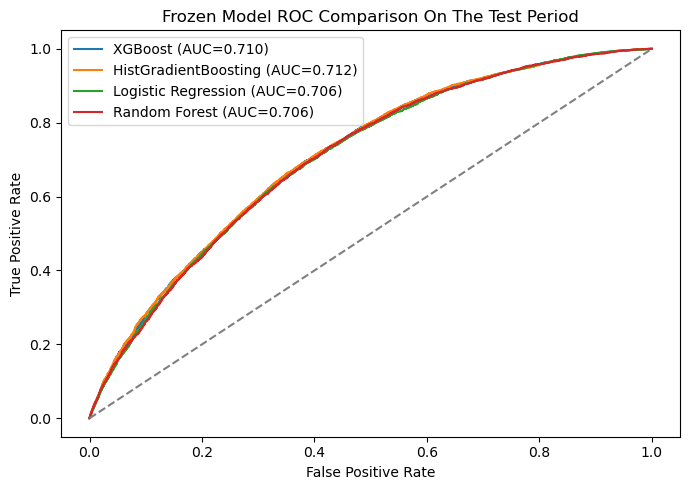

In [11]:
plt.figure(figsize=(7, 5))
for row in interactive_result['final_test_table'].itertuples(index=False):
    roc_data = row.test_metrics['roc_curve']
    plt.plot(roc_data['fpr'], roc_data['tpr'], label=f'{row.model_name} (AUC={row.test_auc:.3f})')

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('Frozen Model ROC Comparison On The Test Period')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Full-Scale Finalization And Markdown Report

The final report always reruns the experiment on full data by forcing `sample_frac = 1.0`, while preserving the same temporal split and search logic.
If feature discovery is enabled, the report also records the omitted feature-group screening table.

In [12]:
if CURRENT_CONFIG['generate_full_report']:
    FINAL_REPORT_CONFIG = copy.deepcopy(CURRENT_CONFIG)
    FINAL_REPORT_CONFIG['sample_frac'] = 1.0

    final_result = run_experiment(FINAL_REPORT_CONFIG, df_model)
    final_feature_search = None
    if FINAL_REPORT_CONFIG['run_feature_search']:
        final_feature_search = run_feature_search(FINAL_REPORT_CONFIG, df_model)

    report_path = write_temporal_report(
        final_result,
        FINAL_REPORT_CONFIG,
        FINAL_REPORT_CONFIG['report_output_path'],
        feature_search_result=final_feature_search,
    )

    export_columns = [
        column
        for column in [
            'sample_id',
            ISSUE_DATE_COLUMN,
            'loan_amnt',
            'annual_inc',
            'fico_range_low',
            'term_months',
            'int_rate',
            'revol_util',
            'actual_default',
            'predicted_pd',
            'model_name',
        ]
        if column in final_result['champion_predictions'].columns
    ]
    champion_predictions = final_result['champion_predictions'][export_columns].copy()
    output_path = Path(FINAL_REPORT_CONFIG['output_path'])
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists():
        output_path.chmod(0o644)
    champion_predictions.to_csv(output_path, index=False)

    final_split_summary = final_result['prepared_data']['split_summary'].copy()
    final_split_summary['default_rate'] = final_split_summary['default_rate'].round(4)
    final_validation_display = final_result['validation_table'][['validation_rank', 'model_name', 'validation_auc', 'validation_ks', 'validation_brier']].copy()
    final_test_display = final_result['final_test_table'][['validation_rank', 'model_name', 'test_auc', 'test_ks', 'test_brier']].copy()
    for table in [final_validation_display, final_test_display]:
        for column in table.columns:
            if column.endswith('auc') or column.endswith('ks') or column.endswith('brier'):
                table[column] = table[column].round(4)

    print(f'Exported {len(champion_predictions):,} test rows to {output_path}.')
    print(f'Wrote Markdown report to {report_path}.')
    display(final_split_summary)
    display(final_validation_display)
    display(final_test_display)
    if final_feature_search is not None:
        final_feature_display = final_feature_search['feature_search_table'][['feature_rank', 'feature_group', 'delta_auc', 'delta_ks', 'delta_brier']].copy()
        for column in ['delta_auc', 'delta_ks', 'delta_brier']:
            final_feature_display[column] = final_feature_display[column].round(4)
        display(final_feature_display)
    display(champion_predictions.head())
else:
    print("Full-scale report generation is disabled. Turn on CURRENT_CONFIG['generate_full_report'] to write the report and champion predictions.")

Exported 225,611 test rows to /Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/test_with_pd_best_model.csv.
Wrote Markdown report to /Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/reports/temporal_model_report.md.


,partition,rows,default_rate,min_issue_date,max_issue_date
0,train,826604,0.1843,2007-06-01,2015-12-01
1,validation,293095,0.2328,2016-01-01,2016-12-01
2,test,225611,0.2128,2017-01-01,2018-12-01


,validation_rank,model_name,validation_auc,validation_ks,validation_brier
0,1,XGBoost,0.7151,0.3123,0.1628
1,2,HistGradientBoosting,0.7151,0.3123,0.1628
2,3,Logistic Regression,0.7115,0.3070,0.2118
3,4,Random Forest,0.7111,0.3056,0.1641


,validation_rank,model_name,test_auc,test_ks,test_brier
0,1,XGBoost,0.7106,0.3063,0.1521
1,2,HistGradientBoosting,0.7112,0.3065,0.1520
2,3,Logistic Regression,0.7035,0.2975,0.2236
3,4,Random Forest,0.7073,0.3010,0.1527


,feature_rank,feature_group,delta_auc,delta_ks,delta_brier
0,1,Application type dummies,0.0001,-0.0001,-0.0000
1,2,Initial list status dummies,-0.0002,0.0009,-0.0002
2,3,Grade dummies,-0.0003,-0.0011,0.0001


,sample_id,issue_date,loan_amnt,annual_inc,fico_range_low,term_months,int_rate,revol_util,actual_default,predicted_pd,model_name
0,421101,2018-03-01,3000.0,52000.0,760.0,36.0,7.34,0.5,0,0.032205,XGBoost
1,421113,2018-03-01,5000.0,55000.0,675.0,36.0,11.98,33.9,0,0.148452,XGBoost
2,421120,2018-03-01,7000.0,40000.0,695.0,36.0,11.98,36.0,0,0.140015,XGBoost
3,421135,2018-03-01,30000.0,57000.0,680.0,36.0,21.85,53.2,0,0.366899,XGBoost
4,421137,2018-03-01,21000.0,85000.0,665.0,60.0,20.39,34.2,0,0.372429,XGBoost
